# 09 — ABCD vs OOT 模型分数分布对比

消费 `scripts/compare_seed_scores.py` 产物（`artifacts/<PRODUCT>/score_compare/<run_id>/`），从分数分布的视角看 ABCD 人群在已训练模型上的表现差异。

和 notebook 08（特征分布对比）的分工：
- 08 看**特征侧**漂移 —— 输入端是否变了
- 09 看**输出侧**漂移 —— 模型的实际打分是否变了，以及业务可直接消费的指标（top-10% 命中率、score PSI、decile 偏移）

通常**输出侧 PSI 比输入侧 PSI 更直接反映模型的可迁移性**：少量特征漂移 + 模型对它们权重低 → 输入侧 PSI 大但输出侧 PSI 小，模型仍可用。

运行前先跑：
```
PYTHONPATH=src python3 scripts/compare_seed_scores.py --product hzz_day --run-id <run_id> --seeds-dir data/seeds
```

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '../src')
from wdm.config import load_config
from wdm.utils.paths import artifacts_root

PRODUCT = 'hzz_day'
RUN_ID = None     # None → 自动选 artifacts/<PRODUCT>/score_compare/ 下最新一个 run

cfg = load_config(PRODUCT)
score_root = Path('..').resolve() / 'artifacts' / PRODUCT / 'score_compare'
if RUN_ID is None:
    runs = sorted([p for p in score_root.iterdir() if p.is_dir()])
    if not runs:
        raise FileNotFoundError('No runs under {0} — run scripts/compare_seed_scores.py first'.format(score_root))
    out_root = runs[-1]
else:
    out_root = score_root / RUN_ID
with open(out_root / 'manifest.json') as f:
    manifest = json.load(f)
print('run             :', manifest['run_id'])
print('bundle dir      :', manifest['bundle_dir'])
print('oot top10 thresh:', '{0:.4f}'.format(manifest['oot_top10_threshold']))
print('sources         :', manifest['sources'])

run             : smoke02
bundle dir      : /Users/pangyexing/work/ai_project/wdmarketing/artifacts/hzz_day/models/smoke02
oot top10 thresh: 0.5022
sources         : {'OOT': 15000, 'A': 3000, 'B': 3000, 'C': 3000, 'D': 3000}


In [2]:
summary = pd.read_csv(out_root / 'score_summary.csv')
quantiles = pd.read_csv(out_root / 'score_quantiles.csv')
psi_tbl = pd.read_csv(out_root / 'score_psi.csv')
deciles = pd.read_csv(out_root / 'score_deciles.csv')

scores = {}
for p in sorted((out_root / 'scores').glob('*.csv')):
    scores[p.stem] = pd.read_csv(p)['score'].values

SOURCES = ['OOT'] + [s for s in summary['source'].tolist() if s != 'OOT']
SEEDS = [s for s in SOURCES if s != 'OOT']
print('sources order :', SOURCES)
summary

sources order : ['OOT', 'A', 'B', 'C', 'D']


,source,n,mean_score,median_score,p90_score,pct_above_oot_top10
0,OOT,15000,0.272103,0.225384,0.502196,0.100000
1,A,3000,0.269778,0.219634,0.499586,0.098667
2,B,3000,0.270842,0.224511,0.509573,0.106667
3,C,3000,0.272456,0.224380,0.508395,0.106667
4,D,3000,0.268172,0.222105,0.494461,0.094667


## 1. 分数直方图叠加 —— 形状对比

OOT 用浅色填充作背景，ABCD 用 step 线叠在上面。直接看「这个人群分数整体是偏左（低分）还是偏右（高分）」。

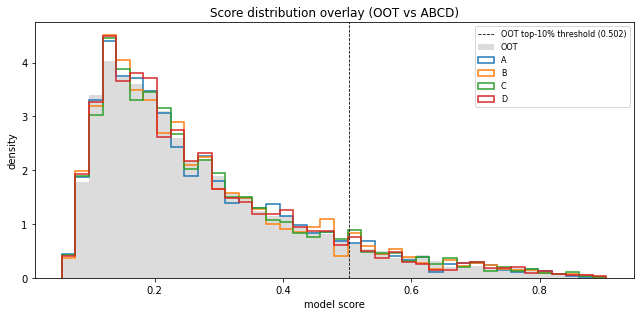

In [3]:
n_bins = 40
score_min = min(s.min() for s in scores.values())
score_max = max(s.max() for s in scores.values())
edges = np.linspace(score_min, score_max, n_bins + 1)
thr = manifest['oot_top10_threshold']

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(scores['OOT'], bins=edges, density=True, color='#bbbbbb', alpha=0.5, label='OOT')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for name, c in zip(SEEDS, colors):
    ax.hist(scores[name], bins=edges, density=True, histtype='step',
            color=c, linewidth=1.5, label=name)
ax.axvline(thr, color='k', linestyle='--', linewidth=0.8,
           label='OOT top-10% threshold ({0:.3f})'.format(thr))
ax.set_xlabel('model score')
ax.set_ylabel('density')
ax.set_title('Score distribution overlay (OOT vs ABCD)')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 2. 累积分布 (CDF) —— 看排序

CDF 更适合回答「这个人群比 OOT 整体偏移多少」：曲线在 OOT 左边 → 人群整体得分更低；在右边 → 更高。

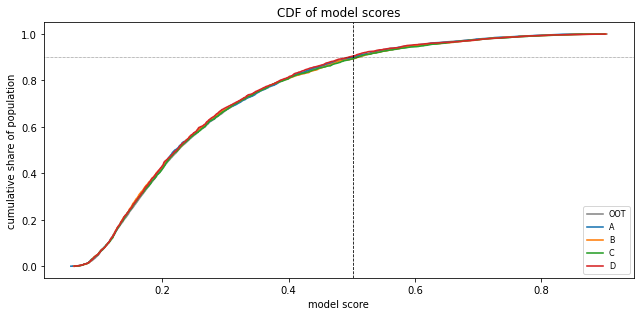

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, c in zip(['OOT'] + SEEDS, ['#888888'] + colors):
    s = np.sort(scores[name])
    y = np.linspace(0, 1, s.size, endpoint=False)
    ax.plot(s, y, color=c, linewidth=1.6, label=name)
ax.axvline(thr, color='k', linestyle='--', linewidth=0.8)
ax.axhline(0.9, color='k', linestyle=':', linewidth=0.5)
ax.set_xlabel('model score')
ax.set_ylabel('cumulative share of population')
ax.set_title('CDF of model scores')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 3. OOT-decile 重新分桶 —— 业务可直接消费

把 OOT 的 score 切成 10 个等频桶（每桶 10%），看 ABCD 每个种子分别有多少比例落进 1~10 号桶。

**读法**：
- 第 10 号桶（最高分）pct >> 10% → 人群对模型来说是「高响应」候选，业务可直接用作触达池
- 第 1 号桶 pct >> 10% → 该人群被模型判低分，不适合此模型的触达策略
- 各桶 pct 都接近 10% → 该人群和 OOT 的分数排序基本一致，模型可平移使用

In [ ]:
pivot = deciles.pivot(index='decile', columns='source', values='pct').reindex(columns=SOURCES)
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(1, 11)
width = 0.8 / len(SOURCES)
for i, src in enumerate(SOURCES):
    color = '#888888' if src == 'OOT' else colors[(i - 1) % len(colors)]
    ax.bar(x + (i - len(SOURCES) / 2 + 0.5) * width, pivot[src].values,
           width=width, label=src, color=color, edgecolor='white', linewidth=0.3)
ax.axhline(0.10, color='k', linestyle=':', linewidth=0.5, label='uniform 10%')
ax.set_xticks(x)
ax.set_xlabel('OOT-derived decile (1 = lowest score, 10 = highest)')
ax.set_ylabel('share of population in this decile')
ax.set_title('Population share by OOT score decile')
ax.legend(fontsize=8, ncol=len(SOURCES) + 1)
fig.tight_layout()
plt.show()

# top decile (最高 10%) enrichment 系数 = seed 的 pct / OOT 的 10%
top10 = pivot.loc[10] / 0.10
print('Top-decile enrichment (seed share / 10%, >1 means enriched in high scorers):')
print(top10.round(3).to_string())

## 4. Score PSI 表 + 分位数表

Score PSI 是「输出侧漂移」的单数字概括：
- < 0.10 stable：模型在该人群上的打分分布与 OOT 一致，可平移使用
- 0.10 ~ 0.25 shift：分布有可观察差异，建议重新校准（calibration）后再用
- ≥ 0.25 broken：需要重训或重新选特征

In [ ]:
print('=== Score PSI (vs OOT) ===')
print(psi_tbl.to_string(index=False))
print()
print('=== Score quantiles (decile + tail) ===')
print(quantiles.set_index('source').round(4).to_string())

## 5. Box plot —— 中位数 / IQR / 尾部一眼对比

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
data = [scores[s] for s in SOURCES]
bp = ax.boxplot(data, labels=SOURCES, showfliers=False, patch_artist=True)
for patch, src in zip(bp['boxes'], SOURCES):
    patch.set_facecolor('#dddddd' if src == 'OOT' else '#a6cee3')
ax.axhline(thr, color='r', linestyle='--', linewidth=0.7,
           label='OOT top-10% ({0:.3f})'.format(thr))
ax.set_ylabel('model score')
ax.set_title('Score box plot per source (whiskers = 1.5×IQR, outliers hidden)')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

---

### 后续动作建议

1. **某个种子 top-decile enrichment >> 1（如 1.5~3x）** → 该人群对模型而言「高响应」概率明显高于 OOT；可直接作为触达池，按 score 排序发券即可。需关注 OOT 测得的 lift 是否还稳定 —— 见 `binned_lift_oot.csv`。
2. **某个种子 top-decile enrichment ≈ 1 但 score PSI > 0.10** → 分布形状变了但排序大致保留；说明绝对分数不可比（不能用原 OOT 阈值直接套），但相对排序可用。建议在该种子上重新选 cutoff。
3. **score PSI ≥ 0.25** → 模型在该人群上behavior 已经不同；优先考虑：(a) 用该种子构造伪标签微调（fine-tune）；(b) 检查 notebook 08 找出哪些特征导致输出漂移；(c) 重新评估业务投放风险。
4. **ABCD 之间互相分布相近但都偏离 OOT** → 4 个种子是同一类新人群（业务定位一致），可合并训练一个 transfer 模型。
5. **A/B（高意向）和 C/D（泛人群）分数分布显著不同** → 符合预期，模型保留了业务上的区分度；可分别配不同触达策略。
6. **A/B（高意向）和 C/D（泛人群）分数没差异** → 模型可能对「意向 vs 泛」的区分不敏感；考虑重新评估特征选择是否覆盖了与意向相关的信号。